# Exploratory Data Analysis & Intro

## Goal

1. Investigate top-paying roles and skills in the data science industry.
2. Use Python to explore a real-live dataset on job postings.
3. For job-seekers: use these insights to help find the best job opportunities.

## Final Deliverables:
- Create Jupyter Notebookss (showcasing core skills in Python).
- Create a summary page (via [README.md](README.md)) capturing your findings.
- Share this project via GitHub & LinkedIn.

## Questions to Answer

1. What are the most demanded skills for the top 3 most popular data roles?
2. How are in-demand skills trending for Data Analysts?
3. How well do jobs and skills pay for Data Analysts?
4. What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying)

I'll be focusing on US Data Analyst roles, but you can adapt to any of the following:



## Exploratory Data Analysis for all Data Roles

### Roles to Explore

In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from load_data import load_data

# Load the cleaned data_jobs dataset.
# First run downloads it from Hugging Face and caches it to data/data_jobs.parquet;
# every later run reads that cache instead. See load_data.py for the details.
df = load_data()

// Testing: Start

> **Note:** Israel was the original target market for this project. After the EDA below
> showed how few Israeli postings carry a salary figure, that plan was dropped and the
> analysis (notebooks 2–5) moved to the United Kingdom. This block is kept as a record of
> the original intent.

1. total jobs per country

In [2]:
df_country_counts = df.copy()
df_country_counts = df_country_counts.groupby('job_country').agg(job_count=('job_country', 'count')).sort_values('job_count', ascending=False).reset_index()
df_country_counts

,job_country,job_count
0,United States,206292
1,India,51088
2,United Kingdom,40375
3,France,39922
4,Germany,27694
...,...,...
155,Guinea,4
156,Bhutan,3
157,Lesotho,3
158,Mauritania,3


2. is a given country in the data?

In [3]:
unique_countries = df['job_country'].unique()
# len(list(unique_countries))
value_to_check = 'Israel'
exists = value_to_check in unique_countries
f"Does {value_to_check} exist? {exists}"

'Does Israel exist? True'

3. Israel positions per job title

In [4]:
il_jobs = df[df['job_country'] == 'Israel'].copy()
il_jobs = il_jobs.groupby('job_title_short').agg(job_count=('job_title_short', 'count')).sort_values('job_count', ascending=False).reset_index()
# il_jobs.loc['Total'] = il_jobs['job_count'].sum() # index damaged
# il_jobs = il_jobs.drop('Total')
il_jobs.loc[len(il_jobs), 'job_title_short'] = 'Total' # index intact
il_jobs.loc[len(il_jobs)-1, 'job_count'] = il_jobs['job_count'].sum()
il_jobs = il_jobs.drop(len(il_jobs)-1)
il_jobs

,job_title_short,job_count
0,Data Analyst,919.0
1,Software Engineer,908.0
2,Data Engineer,801.0
3,Data Scientist,684.0
4,Business Analyst,471.0
5,Senior Data Engineer,288.0
6,Machine Learning Engineer,246.0
7,Senior Data Scientist,235.0
8,Senior Data Analyst,196.0
9,Cloud Engineer,139.0


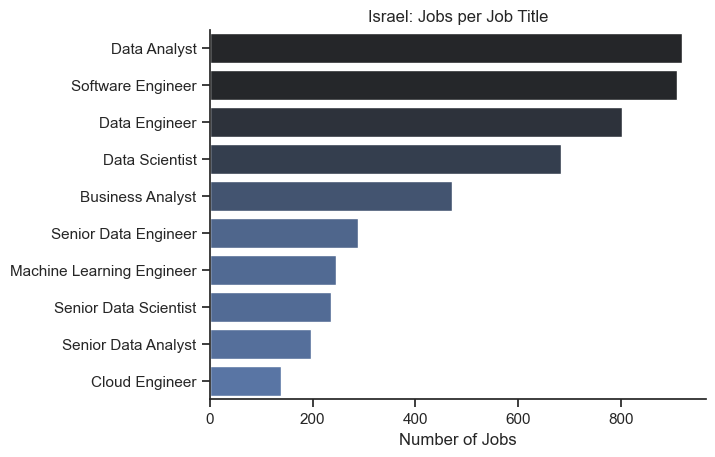

In [5]:
# df_plot = df['job_title_short'].value_counts().to_frame()
# df_plot

il_jobs
sns.set_theme(style='ticks')
sns.barplot(data=il_jobs, x='job_count', y='job_title_short', hue='job_count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Israel: Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

// Testing: End

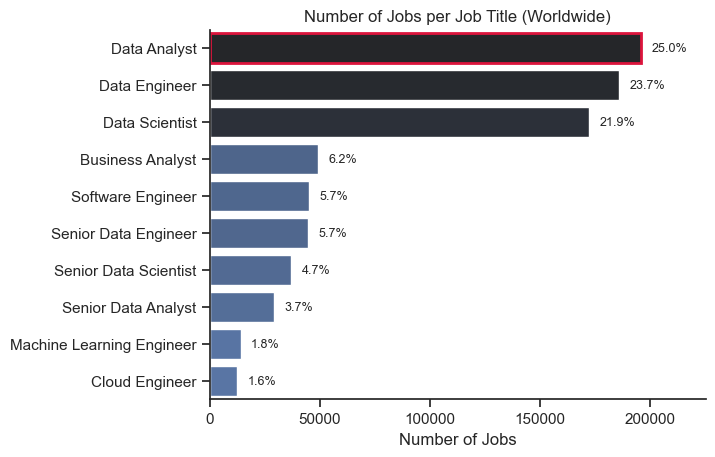

In [6]:
df_plot = df['job_title_short'].value_counts().to_frame()
total_jobs = len(df)

sns.set_theme(style='ticks')
ax = sns.barplot(data=df_plot, x='count', y='job_title_short', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Job Title (Worldwide)')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.xlim(0, df_plot['count'].max() * 1.15)

# label each bar with its share of all worldwide postings
for i, count in enumerate(df_plot['count']):
    ax.text(count + total_jobs * 0.006, i, f'{count / total_jobs:.1%}', va='center', fontsize=9)

# Data Analyst is the role this project focuses on for the rest of the analysis.
# bar patches are drawn bottom-up, i.e. in reverse of df_plot's row order.
da_rank = df_plot.index.get_loc('Data Analyst')
ax.patches[len(df_plot) - 1 - da_rank].set_edgecolor('crimson')
ax.patches[len(df_plot) - 1 - da_rank].set_linewidth(2)

plt.show()

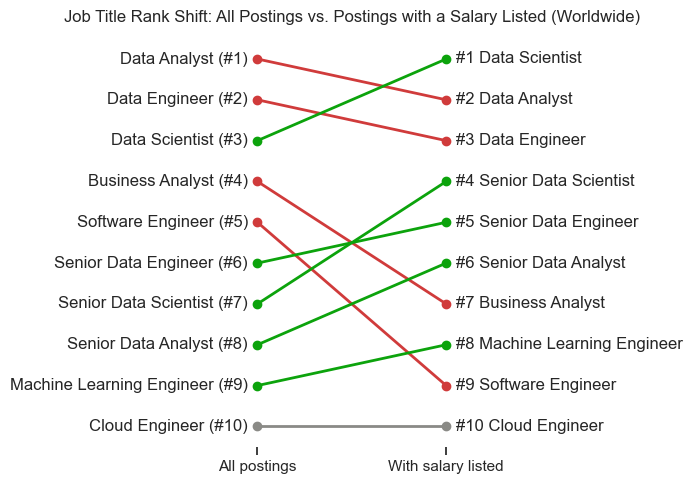

In [7]:
# Does the job-title ranking change if we only look at postings that list a salary?
sal_mask = df['salary_year_avg'].notna()
count_all = df['job_title_short'].value_counts()
count_sal = df.loc[sal_mask, 'job_title_short'].value_counts()
rank_all = pd.Series(range(1, len(count_all) + 1), index=count_all.index)
rank_sal = pd.Series(range(1, len(count_sal) + 1), index=count_sal.index)

title_rank_compare = pd.DataFrame({'rank_all': rank_all, 'rank_sal': rank_sal}).sort_values('rank_all')

fig, ax = plt.subplots(figsize=(7, 5))
for title, row in title_rank_compare.iterrows():
    r_all, r_sal = row['rank_all'], row['rank_sal']
    if r_sal < r_all:
        color = '#0ca30c'  # moved up
    elif r_sal > r_all:
        color = '#d03b3b'  # moved down
    else:
        color = '#8a8a86'  # unchanged
    ax.plot([0, 1], [r_all, r_sal], marker='o', color=color, linewidth=2)
    ax.text(-0.05, r_all, f'{title} (#{r_all})', ha='right', va='center')
    ax.text(1.05, r_sal, f'#{r_sal} {title}', ha='left', va='center')

ax.set_xlim(-0.9, 1.9)
ax.set_ylim(len(title_rank_compare) + 0.5, 0.3)
ax.set_xticks([0, 1])
ax.set_xticklabels(['All postings', 'With salary listed'])
ax.set_yticks([])
sns.despine(ax=ax, left=True, bottom=True)
ax.set_title('Job Title Rank Shift: All Postings vs. Postings with a Salary Listed (Worldwide)')
plt.tight_layout()
plt.show()

### Countries to Explore

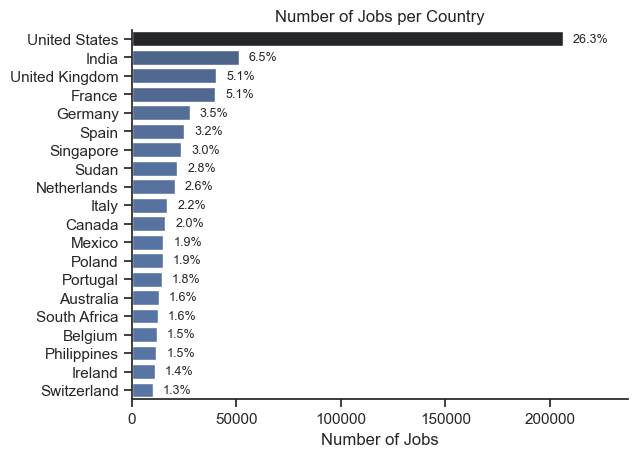

In [8]:
df_plot = df['job_country'].value_counts().to_frame().head(20)
total_jobs = len(df)

sns.set_theme(style='ticks')
ax = sns.barplot(data=df_plot, x='count', y='job_country', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Country')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.xlim(0, df_plot['count'].max() * 1.15)

# label each bar with its share of all worldwide postings
for i, count in enumerate(df_plot['count']):
    ax.text(count + total_jobs * 0.006, i, f'{count / total_jobs:.1%}', va='center', fontsize=9)

plt.show()

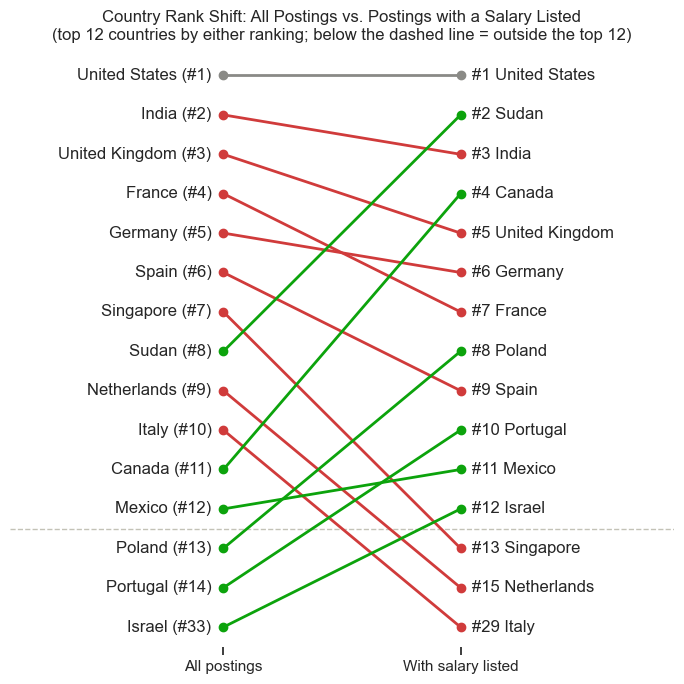

In [9]:
# Does the country ranking change if we only look at postings that list a salary?
sal_mask = df['salary_year_avg'].notna()
count_all = df['job_country'].value_counts()
count_sal = df.loc[sal_mask, 'job_country'].value_counts()
rank_all = pd.Series(range(1, len(count_all) + 1), index=count_all.index)
rank_sal = pd.Series(range(1, len(count_sal) + 1), index=count_sal.index)

top_n = 12
watch_countries = set(rank_all[rank_all <= top_n].index) | set(rank_sal[rank_sal <= top_n].index)
rank_compare = pd.DataFrame({'rank_all': rank_all, 'rank_sal': rank_sal}).loc[list(watch_countries)].astype(int)
rank_compare = rank_compare.sort_values('rank_all')


def display_positions(ranks, top_n):
    # countries ranked inside the window keep their real rank as the y-position;
    # the rest stack in rank order right below it, so none of them overlap
    positions = ranks.clip(upper=top_n).copy()
    overflow = ranks[ranks > top_n].sort_values()
    positions.loc[overflow.index] = range(top_n + 1, top_n + 1 + len(overflow))
    return positions


display_all = display_positions(rank_compare['rank_all'], top_n)
display_sal = display_positions(rank_compare['rank_sal'], top_n)
bottom_row = max(display_all.max(), display_sal.max())

fig, ax = plt.subplots(figsize=(7, 7))
ax.axhline(top_n + 0.5, color='#c3c2b7', linewidth=1, linestyle='--')
for country in rank_compare.index:
    r_all, r_sal = rank_compare.loc[country, 'rank_all'], rank_compare.loc[country, 'rank_sal']
    y_all, y_sal = display_all[country], display_sal[country]
    if r_sal < r_all:
        color = '#0ca30c'  # moved up
    elif r_sal > r_all:
        color = '#d03b3b'  # moved down
    else:
        color = '#8a8a86'  # unchanged
    ax.plot([0, 1], [y_all, y_sal], marker='o', color=color, linewidth=2)
    ax.text(-0.05, y_all, f'{country} (#{r_all})', ha='right', va='center')
    ax.text(1.05, y_sal, f'#{r_sal} {country}', ha='left', va='center')

ax.set_xlim(-0.9, 1.9)
ax.set_ylim(bottom_row + 0.5, 0.3)
ax.set_xticks([0, 1])
ax.set_xticklabels(['All postings', 'With salary listed'])
ax.set_yticks([])
sns.despine(ax=ax, left=True, bottom=True)
ax.set_title(f'Country Rank Shift: All Postings vs. Postings with a Salary Listed\n'
             f'(top {top_n} countries by either ranking; below the dashed line = outside the top {top_n})')
plt.tight_layout()
plt.show()

### Companies to Explore

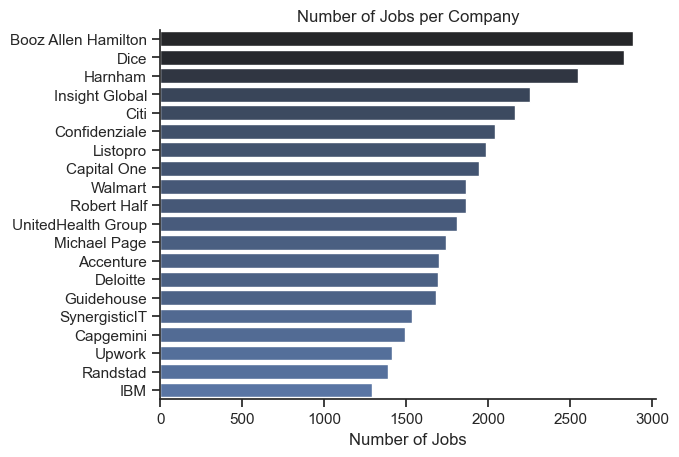

In [10]:
df_plot = df['company_name'].value_counts().to_frame()[1:].head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Company')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Job Opportunities

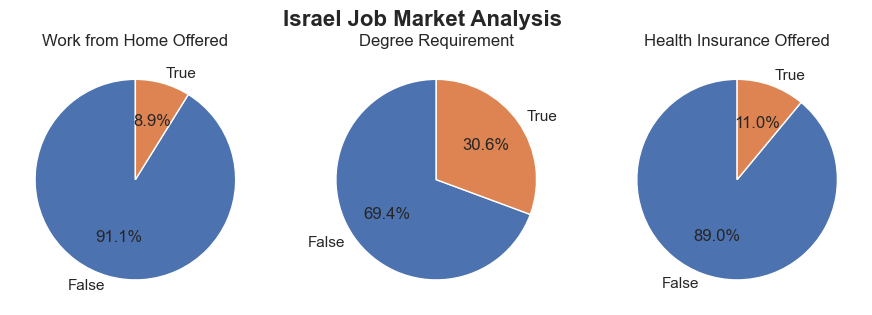

In [11]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
fig.suptitle('Israel Job Market Analysis', fontsize=16, fontweight='bold') # IL data

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

## Exploratory Data Analysis for Data Analysts in the US

In [12]:
# The dataset is already loaded in the first code cell via load_data().
# No need to download or clean it again here.

### Filter for US Data Analyst roles

In [13]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

### Locations to Explore:

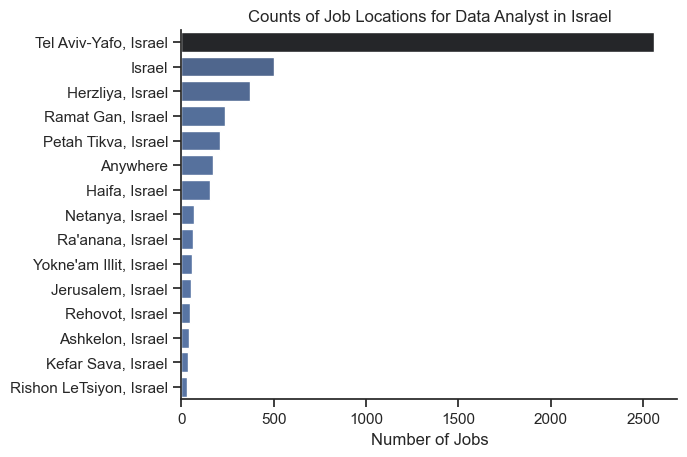

In [14]:
# df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()
df_plot = df[df['job_country'] == 'Israel']['job_location'].value_counts().head(15).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in Israel')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Job Opportunities

// Testing: Start

4. validate IL data

In [15]:
# boolean_fields_il = df[df['job_country'] == 'Israel'][['job_work_from_home','job_no_degree_mention','job_health_insurance']].value_counts()
job_work_from_home = df[df['job_country'] == 'Israel']['job_work_from_home'].value_counts()
job_no_degree_mention = df[df['job_country'] == 'Israel']['job_no_degree_mention'].value_counts()
job_health_insurance = df[df['job_country'] == 'Israel']['job_health_insurance'].value_counts()
job_work_from_home, job_no_degree_mention, job_health_insurance

(job_work_from_home
 False    4715
 True      172
 Name: count, dtype: int64,
 job_no_degree_mention
 False    3401
 True     1486
 Name: count, dtype: int64,
 job_health_insurance
 False    4883
 True        4
 Name: count, dtype: int64)

// Testing: End

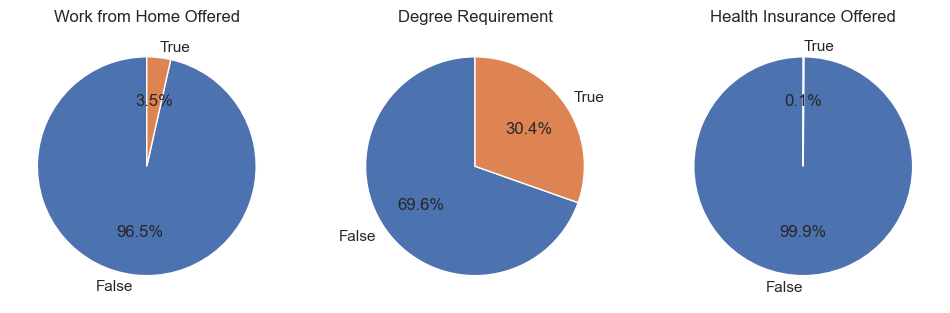

In [16]:
# rewrite the above with a for loop
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    # ax[i].pie(df_DA_US[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].pie(df[df['job_country'] == 'Israel'][column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90) # IL data
    ax[i].set_title(title)

# plt.suptitle('Benefit Analysis of Data Jobs', fontsize=16)
plt.show()

### Companies to Explore:

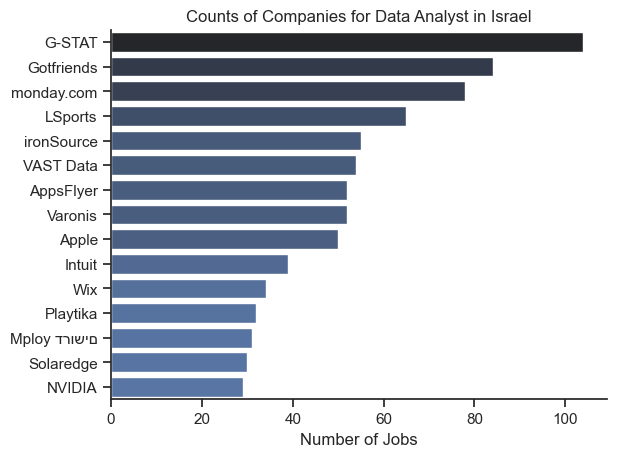

In [17]:
# df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()
df_plot = df[df['job_country'] == 'Israel']['company_name'].value_counts().head(15).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in Israel')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()